In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error


df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [2]:
X = df.drop(columns=['Exam_Score'])
y = df['Exam_Score']


X['Teacher_Quality'] = X['Teacher_Quality'].fillna(X['Teacher_Quality'].mode()[0])
X['Parental_Education_Level'] = X['Parental_Education_Level'].fillna(X['Parental_Education_Level'].mode()[0])
X['Distance_from_Home'] = X['Distance_from_Home'].fillna(X['Distance_from_Home'].mode()[0])

print("Missing values after imputation:\n", X.isnull().sum().sum())

Missing values after imputation:
 0


In [3]:
ordinal_cols = ['Parental_Involvement', 'Motivation_Level', 'Family_Income', 'Teacher_Quality']
nominal_cols = ['Access_to_Resources', 'Extracurricular_Activities', 'Internet_Access', 
                'School_Type', 'Peer_Influence', 'Learning_Disabilities', 
                'Parental_Education_Level', 'Distance_from_Home', 'Gender']
numeric_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
                'Tutoring_Sessions', 'Physical_Activity']

mapping_order = [
    ['Low', 'Medium', 'High'],      # Parental_Involvement
    ['Low', 'Medium', 'High'],      # Motivation_Level
    ['Low', 'Medium', 'High'],      # Family_Income
    ['Low', 'Medium', 'High']       # Teacher_Quality
]

# Build the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=mapping_order), ordinal_cols),
        ('nom', OneHotEncoder(drop='first', sparse_output=False), nominal_cols),
        ('num', StandardScaler(), numeric_cols)
    ])

# 20% split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
# just to remove large anoying warrnings
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'


# Initialize and train the model (starting with K=5)
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_processed, y_train)

# Predict the scores on the test set
y_pred = knn_reg.predict(X_test_processed)

# 1. Calculate Standard Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# 2. Calculate Adjusted R-squared
# n = number of observations, p = number of predictors (features)
n = len(y_test)
p = X_test_processed.shape[1]
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# 3. Print out the full diagnostic report
print("--- COMPREHENSIVE KNN REGRESSION METRICS (K=5) ---")
print(f"Mean Absolute Error (MAE):             {mae:.2f} (Average error in exam points)")
print(f"Mean Squared Error (MSE):              {mse:.2f}")
print(f"Root Mean Squared Error (RMSE):        {rmse:.2f} (Heavily penalizes large errors)")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2%} (Average percentage error)")
print(f"R-squared (R2 Score):                  {r2:.4f} (Proportion of variance explained)")
print(f"Adjusted R-squared:                    {adj_r2:.4f} (Adjusted for number of features)")

--- COMPREHENSIVE KNN REGRESSION METRICS (K=5) ---
Mean Absolute Error (MAE):             1.39 (Average error in exam points)
Mean Squared Error (MSE):              5.75
Root Mean Squared Error (RMSE):        2.40 (Heavily penalizes large errors)
Mean Absolute Percentage Error (MAPE): 2.04% (Average percentage error)
R-squared (R2 Score):                  0.5936 (Proportion of variance explained)
Adjusted R-squared:                    0.5864 (Adjusted for number of features)


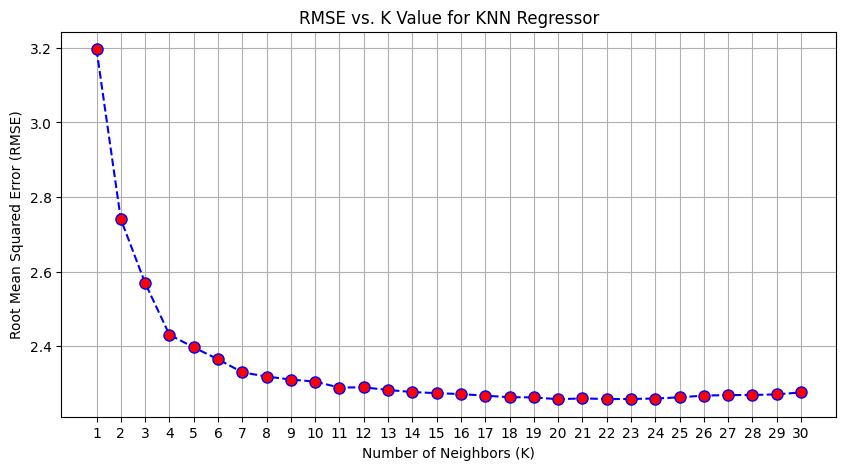

The optimal number of neighbors is K = 20 with the lowest RMSE of 2.26


In [7]:
rmse_values = []
k_range = range(1, 31)

# Test K values from 1 to 30
for k in k_range:
    knn_temp = KNeighborsRegressor(n_neighbors=k)
    knn_temp.fit(X_train_processed, y_train)
    predictions = knn_temp.predict(X_test_processed)
    rmse_values.append(np.sqrt(mean_squared_error(y_test, predictions)))

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(k_range, rmse_values, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=8)
plt.title('RMSE vs. K Value for KNN Regressor')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

best_k = k_range[np.argmin(rmse_values)]
print(f"The optimal number of neighbors is K = {best_k} with the lowest RMSE of {min(rmse_values):.2f}")

In [9]:
# ok now for k=20
final_knn = KNeighborsRegressor(n_neighbors=20)
final_knn.fit(X_train_processed, y_train)

# Make the final predictions on the test set
final_pred = final_knn.predict(X_test_processed)

# Calculate final optimized metrics
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)

print("--- FINAL OPTIMIZED KNN MODEL (K=20) ---")
print(f"Final MAE:  {final_mae:.2f}")
print(f"Final RMSE: {final_rmse:.2f}")
print(f"Final R2:   {final_r2:.4f}")

--- FINAL OPTIMIZED KNN MODEL (K=20) ---
Final MAE:  1.26
Final RMSE: 2.26
Final R2:   0.6393
